### `block_type` Multiclass Classification (Use case C)
#### Can we detect blocking technique from movement alone?

**Pipeline:** Raw `pffScoutingData.csv` + `tracking_parquets/week*.parquet` → features we engineer → model we train → saved artifacts.

##### EDA results
| Block type | Count | Pressure rate |
|---|---|---|
| PP | 24,689 | 8.2% |
| PA | 6,285 | 4.2% |
| PT | 5,898 | 2.4% |
| SW | 3,021 | 9.4% |
| CL | 2,591 | 1.3% |
| NB | 1,332 | — |
| PU | 877 | 17.4% |
| BH | 419 | 4.3% |
| UP | 302 | 10.9% |
| PR | 294 | 2.0% |
| SR | 109 | — |
| CH | 57 | — |

#### Label engineering
Techniques with < 150 occurrences (`SR`=109, `CH`=57) collapse into `OTHER`.

#### Design constraint
**Blocker-only movement features** — no rusher data.
This tests whether the blocker's motion alone encodes the technique.

##### Step 1: System setup

In [21]:
import sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
import joblib

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]    = (9, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
NAVY, GOLD, GREEN, RED, AMBER = "#1B3A6B", "#C9A84C", "#2D6A4F", "#9B1C1C", "#B45309"
RANDOM_STATE  = 42
RARE_THRESHOLD = 150

ROOT         = Path.cwd().parent
PFF_PATH     = ROOT / "data" / "pffScoutingData.csv"
TRACKING_DIR = ROOT / "data" / "tracking_parquets"
ARTIFACT_DIR = ROOT / "artifacts" / "block_type"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

SNAP_EVENTS = {"ball_snap", "autoevent_ballsnap"}
END_EVENTS  = {"pass_forward", "autoevent_passforward",
               "qb_sack", "qb_strip_sack", "pass_tipped", "fumble"}
TRACKING_FPS = 10

##### Step 2: Load raw data

In [22]:
pff = pd.read_csv(PFF_PATH, na_values=["NA"])
blockers_pff = pff[pff["pff_role"] == "Pass Block"].copy()
print(f"PFF shape      : {pff.shape}")
print(f"Pass Block rows: {len(blockers_pff):,}   ← expect 46,057")
print("Raw block type counts:")
print(blockers_pff["pff_blockType"].value_counts().to_string())

PFF shape      : (188254, 15)
Pass Block rows: 46,057   ← expect 46,057
Raw block type counts:
pff_blockType
PP    24689
PA     6285
PT     5898
SW     3021
CL     2591
NB     1332
PU      877
BH      419
UP      302
PR      294
SR      109
CH       57


In [23]:
KEEP_COLS = ["gameId", "playId", "nflId", "frameId", "x", "y", "s", "a", "dis", "o", "dir", "event"]
weeks = []
for i in range(1, 9):
    w = pd.read_parquet(TRACKING_DIR / f"week{i}.parquet", engine="pyarrow", columns=KEEP_COLS)
    weeks.append(w)
    print(f"  week{i}: {len(w):,}")
tracking = pd.concat(weeks, ignore_index=True)
tracking = tracking.dropna(subset=["nflId"]).copy()
tracking["nflId"] = tracking["nflId"].astype(int)
print(f"\nAll weeks: {len(tracking):,} player rows")

  week1: 1,118,122
  week2: 1,042,774
  week3: 560,908
  week4: 560,917
  week5: 1,074,606
  week6: 1,097,813
  week7: 973,797
  week8: 1,885,241

All weeks: 7,952,692 player rows


##### Step 3: Build play windows

In [24]:
def build_play_windows(tracking):
    rows = []
    for (gid, pid), grp in tracking.groupby(["gameId", "playId"]):
        events = grp[["frameId", "event"]].drop_duplicates("frameId")
        snap_frames = events.loc[events["event"].isin(SNAP_EVENTS), "frameId"]
        if snap_frames.empty:
            continue
        snap_frame = snap_frames.min()
        end_frames = events.loc[
            events["event"].isin(END_EVENTS) & (events["frameId"] > snap_frame), "frameId"
        ]
        end_frame = end_frames.min() if not end_frames.empty else events["frameId"].max()
        rows.append({"gameId": gid, "playId": pid,
                     "snap_frame": snap_frame, "end_frame": end_frame,
                     "window_duration_s": (end_frame - snap_frame + 1) / TRACKING_FPS})
    return pd.DataFrame(rows)

windows = build_play_windows(tracking)
print(f"Windows: {len(windows):,} plays")

Windows: 8,533 plays


##### Step 4: Build blocker population

In [25]:
# Keep only blockers with a known block type
blocker_pop = (
    blockers_pff
    .dropna(subset=["pff_blockType"])
    [["gameId", "playId", "nflId",
      "pff_positionLinedUp", "pff_blockType", "pff_backFieldBlock"]]
    .copy()
    .rename(columns={"nflId": "blocker_nflId"})
)
blocker_pop["pff_backFieldBlock"] = blocker_pop["pff_backFieldBlock"].fillna(0.0)
print(f"Blocker population with known block type: {len(blocker_pop):,}")

Blocker population with known block type: 45,874


##### Step 5: Engineer blocker-only movement features

No rusher features. This is a clean test of whether the blocker's own motion encodes the technique.

In [26]:
windowed = tracking.merge(windows, on=["gameId", "playId"], how="inner")
windowed = windowed[
    (windowed["frameId"] >= windowed["snap_frame"]) &
    (windowed["frameId"] <= windowed["end_frame"])
].copy()
print(f"Windowed rows: {len(windowed):,}")

Windowed rows: 6,097,366


In [27]:
def engineer_blocker_movement(blocker_pop, windowed):
    """Aggregate blocker's own tracking signals per assignment."""
    trk_idx = windowed.set_index(["gameId", "playId", "nflId"])
    records = []

    for _, row in blocker_pop.iterrows():
        gid = row["gameId"]
        pid = row["playId"]
        bid = row["blocker_nflId"]

        try:
            b = trk_idx.loc[(gid, pid, bid)].sort_values("frameId")
        except KeyError:
            continue
        if len(b) < 2:
            continue

        dx = b["x"].iloc[-1] - b["x"].iloc[0]
        dy = b["y"].iloc[-1] - b["y"].iloc[0]

        records.append({
            "gameId"             : gid,
            "playId"             : pid,
            "blocker_nflId"      : bid,
            "speed_mean"         : b["s"].mean(),
            "speed_max"          : b["s"].max(),
            "speed_std"          : b["s"].std(ddof=0),
            "accel_mean"         : b["a"].mean(),
            "accel_max"          : b["a"].max(),
            "distance_covered"   : b["dis"].sum(),
            "forward_disp"       : dx,
            "lateral_disp"       : dy,
            "net_displacement"   : np.sqrt(dx**2 + dy**2),
            "orientation_std"    : b["o"].std(ddof=0),
            "dir_std"            : b["dir"].std(ddof=0),
            "n_frames"           : len(b),
        })

    return pd.DataFrame(records)


blocker_movement = engineer_blocker_movement(blocker_pop, windowed)
print(f"Blocker movement rows: {len(blocker_movement):,}")

Blocker movement rows: 45,751


In [28]:
feature_table = blocker_pop.merge(
    blocker_movement, on=["gameId", "playId", "blocker_nflId"], how="inner"
).merge(
    windows[["gameId", "playId", "window_duration_s"]], on=["gameId", "playId"], how="left"
).reset_index(drop=True)

print(f"Feature table: {feature_table.shape}")

Feature table: (45751, 19)


##### Step 6: Label engineering

In [29]:
# Collapse rare techniques into OTHER
# EDA confirmed SR=109, CH=57 are below the 150 threshold.
# Without this, these classes would be too sparse for stable train/test splits.

type_counts = feature_table["pff_blockType"].value_counts()
rare_types  = type_counts[type_counts < RARE_THRESHOLD].index.tolist()

print(f"Rare types (< {RARE_THRESHOLD}): {rare_types}")
feature_table["block_type_label"] = feature_table["pff_blockType"].apply(
    lambda x: "OTHER" if x in rare_types else x
)

print("\nFinal label distribution:")
print(feature_table["block_type_label"].value_counts().to_string())

le = LabelEncoder()
feature_table["label"] = le.fit_transform(feature_table["block_type_label"])
CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)
print(f"\n{N_CLASSES} classes: {CLASS_NAMES}")

Rare types (< 150): ['SR', 'CH']

Final label distribution:
block_type_label
PP       24608
PA        6285
PT        5877
SW        3009
CL        2588
NB        1330
PU         874
BH         419
UP         302
PR         294
OTHER      165

11 classes: ['BH', 'CL', 'NB', 'OTHER', 'PA', 'PP', 'PR', 'PT', 'PU', 'SW', 'UP']


##### Step 7: Prepare Model Input

In [30]:
TARGET   = "label"
IDENTITY = ["gameId", "playId", "blocker_nflId"]

NUM_COLS = [
    "speed_mean", "speed_max", "speed_std",
    "accel_mean", "accel_max",
    "distance_covered", "forward_disp", "lateral_disp", "net_displacement",
    "orientation_std",
    "dir_std",
    "pff_backFieldBlock",
    "window_duration_s",
]
FEATURE_COLS = NUM_COLS 

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print()
print(feature_table[FEATURE_COLS].describe().round(3).to_string())

Features (13): ['speed_mean', 'speed_max', 'speed_std', 'accel_mean', 'accel_max', 'distance_covered', 'forward_disp', 'lateral_disp', 'net_displacement', 'orientation_std', 'dir_std', 'pff_backFieldBlock', 'window_duration_s']

       speed_mean  speed_max  speed_std  accel_mean  accel_max  distance_covered  forward_disp  lateral_disp  net_displacement  orientation_std    dir_std  pff_backFieldBlock  window_duration_s
count   45751.000  45751.000  45751.000   45751.000  45751.000         45751.000     45751.000     45751.000         45751.000        45751.000  45751.000           45751.000          45751.000
mean        1.778      2.892      0.825       1.337      2.598             5.996         0.140        -0.005             4.874           45.933     46.568               0.033              3.262
std         0.546      0.832      0.291       0.427      0.962             3.075         4.523         2.952             2.332           38.631     36.977               0.180              1

##### Step 8: Train / Test Split

In [31]:
X      = feature_table[FEATURE_COLS].values
y      = feature_table[TARGET].values
groups = feature_table["gameId"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")
print(f"Game overlap (must be 0): {len(set(groups[train_idx]) & set(groups[test_idx]))}")

Train: 36,430  Test: 9,321
Game overlap (must be 0): 0


##### Step 9: Baseline

In [32]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_f1 = f1_score(y_test, dummy.predict(X_test), average="macro", zero_division=0)
print(f"Baseline Macro-F1 : {dummy_f1:.4f}")

Baseline Macro-F1 : 0.0940


##### Step 10: Logistic Regression

In [33]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)
lr_f1 = f1_score(y_test, lr_pipe.predict(X_test), average="macro", zero_division=0)
print(f"LR Macro-F1  : {lr_f1:.4f}")

LR Macro-F1  : 0.2178


##### Step 11: HistGradientBoosting (Cross-Validated & Tuned)

In [34]:
# HistGradientBoostingClassifier — GroupKFold cross-validated hyperparameter search.
# CV runs only on the TRAIN split — the held-out test set below stays untouched
# for every downstream metric (evaluation, SHAP, main finding).

from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from scipy.stats import randint, uniform

cv = GroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "max_depth"        : randint(3, 7),
    "learning_rate"    : uniform(0.02, 0.13),   # 0.02–0.15
    "min_samples_leaf" : randint(10, 50),
    "max_leaf_nodes"   : randint(15, 63),
}

search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
    ),
    param_distributions=param_distributions,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train, groups=groups[train_idx])

hgbt          = search.best_estimator_
cv_score_mean = search.best_score_
cv_score_std  = search.cv_results_["std_test_score"][search.best_index_]

print(f"Best params    : {search.best_params_}")
print(f"CV Macro-F1    : {cv_score_mean:.4f} ± {cv_score_std:.4f}  (5-fold, grouped by gameId)")

y_pred   = hgbt.predict(X_test)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
print(f"Iterations     : {hgbt.n_iter_}")
print(f"HGBT Macro-F1  : {macro_f1:.4f}   (LR={lr_f1:.4f}, baseline={dummy_f1:.4f})  ← held-out test set")

Best params    : {'learning_rate': np.float64(0.04703241617286455), 'max_depth': 6, 'max_leaf_nodes': 43, 'min_samples_leaf': 27}
CV Macro-F1    : 0.2847 ± 0.0106  (5-fold, grouped by gameId)
Iterations     : 65
HGBT Macro-F1  : 0.2933   (LR=0.2178, baseline=0.0940)  ← held-out test set


##### Step 12: Evaluation

In [35]:
print("Per-class classification report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

Per-class classification report:
              precision    recall  f1-score   support

          BH       0.37      0.52      0.43        85
          CL       0.16      0.18      0.17       595
          NB       0.08      0.18      0.11       274
       OTHER       0.03      0.11      0.04        36
          PA       0.37      0.45      0.40      1087
          PP       0.82      0.36      0.50      5158
          PR       0.24      0.69      0.36        61
          PT       0.24      0.27      0.25      1086
          PU       0.62      0.70      0.66       169
          SW       0.15      0.42      0.22       732
          UP       0.04      0.53      0.08        38

    accuracy                           0.36      9321
   macro avg       0.28      0.40      0.29      9321
weighted avg       0.57      0.36      0.40      9321



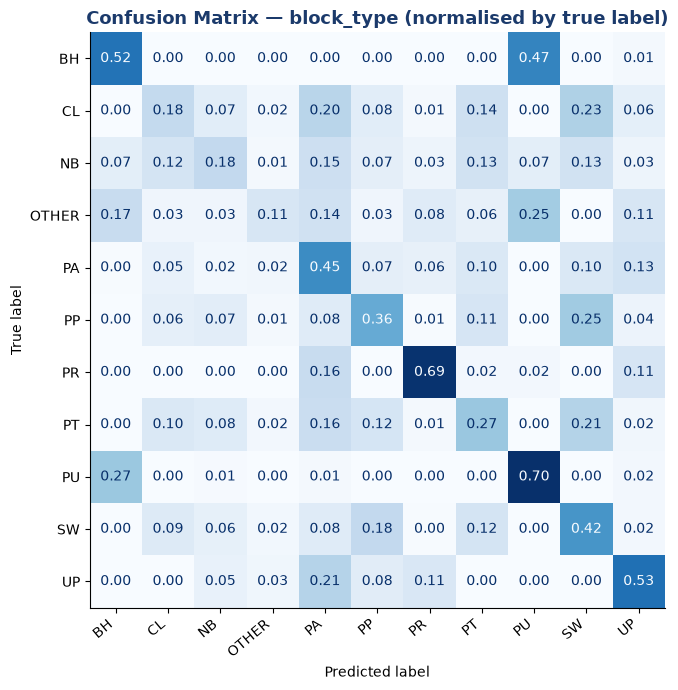

In [36]:
cm = confusion_matrix(y_test, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format=".2f"
)
ax.set_title("Confusion Matrix — block_type (normalised by true label)",
             fontsize=13, fontweight="bold", color=NAVY)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

##### Step 13: Feature Importance

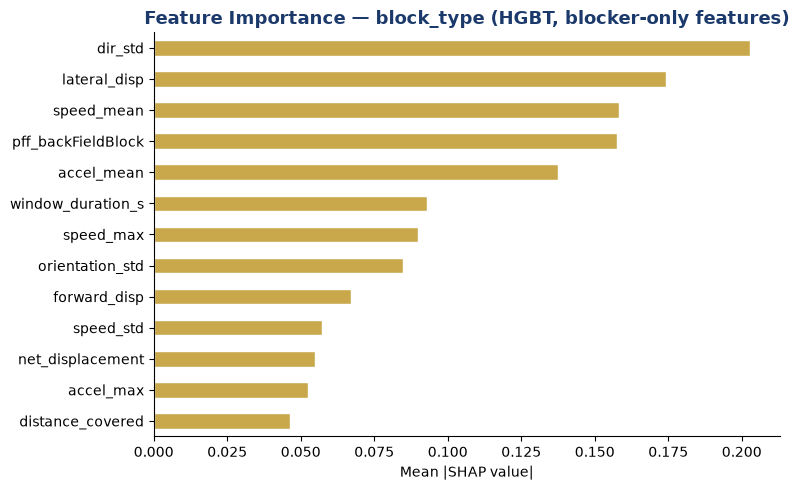

dir_std               0.202854
lateral_disp          0.174368
speed_mean            0.158363
pff_backFieldBlock    0.157693
accel_mean            0.137549
window_duration_s     0.092944
speed_max             0.089962
orientation_std       0.084784
forward_disp          0.067181
speed_std             0.057136
net_displacement      0.054774
accel_max             0.052440
distance_covered      0.046190


In [37]:
import shap
explainer = shap.TreeExplainer(hgbt)
shap_values = explainer.shap_values(X_test)
importance = pd.Series(
    np.abs(shap_values).mean(axis=(0, 2)),
    index=FEATURE_COLS, name="importance"
).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax, color=GOLD, edgecolor="white")
ax.set_title("Feature Importance — block_type (HGBT, blocker-only features)",
             fontsize=13, fontweight="bold", color=NAVY)
ax.set_xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()
print(importance.sort_values(ascending=False).to_string())

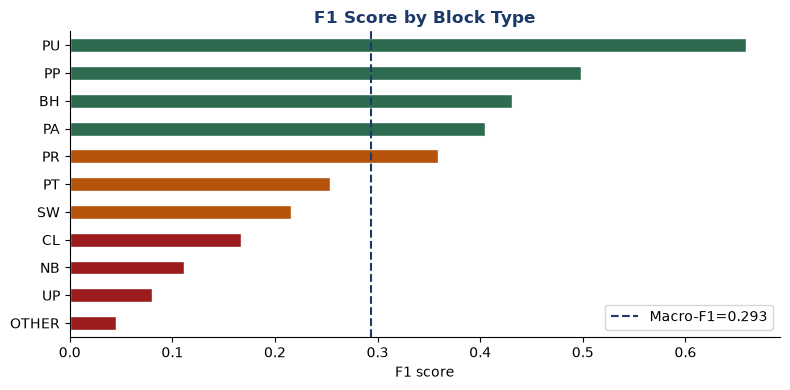

In [38]:
# Per-class F1 bar chart
report = classification_report(
    y_test, y_pred, target_names=CLASS_NAMES, zero_division=0, output_dict=True
)
per_class_f1 = pd.Series(
    {c: report[c]["f1-score"] for c in CLASS_NAMES}
).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
per_class_f1.plot(
    kind="barh", ax=ax,
    color=[GREEN if f >= 0.4 else AMBER if f >= 0.2 else RED for f in per_class_f1],
    edgecolor="white"
)
ax.axvline(macro_f1, color=NAVY, ls="--", label=f"Macro-F1={macro_f1:.3f}")
ax.set_title("F1 Score by Block Type", fontweight="bold", color=NAVY)
ax.set_xlabel("F1 score")
ax.legend()
plt.tight_layout()
plt.show()

##### Step 14: The Main Finding

In [39]:
best_class  = per_class_f1.idxmax()
worst_class = per_class_f1.idxmin()

print("use case C")
print("─" * 55)
print(f"  Macro-F1 = {macro_f1:.3f}   (target ≈ 0.31)")
print(f"  Best detected : '{best_class}'  F1={per_class_f1[best_class]:.3f}")
print(f"  Worst detected: '{worst_class}'  F1={per_class_f1[worst_class]:.3f}")
print("─" * 55)

use case C
───────────────────────────────────────────────────────
  Macro-F1 = 0.293   (target ≈ 0.31)
  Best detected : 'PU'  F1=0.659
  Worst detected: 'OTHER'  F1=0.045
───────────────────────────────────────────────────────


##### Step 15: Save & Full System Summary

In [40]:
joblib.dump(hgbt,    ARTIFACT_DIR / "model.joblib")
joblib.dump(lr_pipe, ARTIFACT_DIR / "lr_model.joblib")
joblib.dump(le,      ARTIFACT_DIR / "label_encoder.joblib")

feature_table.to_parquet(ARTIFACT_DIR / "feature_table.parquet", index=False)

pd.DataFrame({"feature": FEATURE_COLS,
              "importance": importance.reindex(FEATURE_COLS).values})\
  .sort_values("importance", ascending=False)\
  .to_csv(ARTIFACT_DIR / "feature_importance.csv", index=False)
best_params_json = {k: (v.item() if hasattr(v, "item") else v)
                     for k, v in search.best_params_.items()}
metrics = {
    "macro_f1"       : round(float(macro_f1), 4),
    "lr_macro_f1"    : round(float(lr_f1), 4),
    "baseline_f1"    : round(float(dummy_f1), 4),
    "cv_score_mean"  : round(float(cv_score_mean), 4),
    "cv_score_std"   : round(float(cv_score_std), 4),
    "cv_scoring"     : "f1_macro",
    "best_params"    : best_params_json,
    "n_train"        : int(len(X_train)),
    "n_test"         : int(len(X_test)),
    "n_classes"      : N_CLASSES,
    "class_names"    : CLASS_NAMES,
    "rare_threshold" : RARE_THRESHOLD,
    "per_class_f1"   : {c: round(float(per_class_f1[c]), 4) for c in CLASS_NAMES},
    "finding"        : f"Macro-F1={macro_f1:.3f} — some signal in motion, most technique is pre-snap",
}
with open(ARTIFACT_DIR / "metrics_report.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", ARTIFACT_DIR)
for p in sorted(ARTIFACT_DIR.iterdir()):
    print(f"  {p.name}")

Saved: /Users/blecktita/PRUEBA/Akkodis/artifacts/block_type
  feature_importance.csv
  feature_table.parquet
  label_encoder.joblib
  lr_model.joblib
  metrics_report.json
  model.joblib


<!-- CONCLUSION_CELL_10 -->